In [1]:
import cv2
from segment_anything import build_sam, SamAutomaticMaskGenerator
from PIL import Image, ImageDraw
import clip
import torch
import numpy as np
import os

In [2]:
# 处理图像数据
image_path = "/workspaces/assemblyhelper/assets/parts/parts_3.jpg"
im = cv2.imread(image_path)
w_h = 512
height, width, _ = im.shape
ratio = max(width, height) / w_h
new_width = int(width / ratio)
new_height = int(height / ratio)
im = cv2.resize(im, (new_width, new_height))

print(f"origin: {width},{height}")
print(f"resize: {new_width},{new_height}")
cv2.imwrite(image_path, im)

origin: 410,512
resize: 410,512


True

In [3]:
# Download the model weights to load them here
device = "cuda"
sam = build_sam(checkpoint="/workspaces/assemblyhelper/VM/sam_vit_h_4b8939.pth").to(device)
mask_generator = SamAutomaticMaskGenerator(sam, points_per_side=32, pred_iou_thresh=0.98, crop_n_layers=0)

In [4]:
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
masks = mask_generator.generate(image)

In [5]:
masks[0]
print(len(masks))

13


In [6]:
def convert_box_xywh_to_xyxy(box):
    x1 = box[0]
    y1 = box[1]
    x2 = box[0] + box[2]
    y2 = box[1] + box[3]
    return [x1, y1, x2, y2]

In [7]:
def segment_image(image, segmentation_mask):
    image_array = np.array(image)
    segmented_image_array = np.zeros_like(image_array)

#     print(f"{image_array.shape}")
#     print(f"{len(segmentation_mask)},{len(segmentation_mask[0])}")
#     print(f"{image.size}")
    
    segmented_image_array[segmentation_mask] = image_array[segmentation_mask]
    segmented_image = Image.fromarray(segmented_image_array)
    black_image = Image.new("RGB", image.size, (0, 0, 0))
    transparency_mask = np.zeros_like(segmentation_mask, dtype=np.uint8)
    transparency_mask[segmentation_mask] = 255
    transparency_mask_image = Image.fromarray(transparency_mask, mode='L')
    black_image.paste(segmented_image, mask=transparency_mask_image)
    return black_image

In [8]:
# Cut out all masks
image = Image.open(image_path)
cropped_boxes = []

for mask in masks:
    cropped_boxes.append(segment_image(image, mask["segmentation"]).crop(convert_box_xywh_to_xyxy(mask["bbox"])))

In [9]:
# Load CLIP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/32", device=device)

In [10]:
with torch.no_grad():
    def retriev(elements, search_label: str) -> int:
        # process imgs
        preprocessed_images = [preprocess(image).to(device) for image in elements]
        stacked_images = torch.stack(preprocessed_images)
        image_features = model.encode_image(stacked_images)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        # process labels
        label_features = []
        for label in search_label:
            preprocessed_label = torch.stack([preprocess(l).to(device) for l in label])
            label_feature = model.encode_image(preprocessed_label)
            label_feature /= label_feature.norm(dim=-1, keepdim=True)
            label_feature = torch.mean(label_feature, dim=0, keepdim=False)
            label_features.append(label_feature)
        label_features = torch.stack(label_features)

        # Calculate similar scores
    #     print(f"image_shape:{image_features.shape}")
    #     print(f"text_shape:{label_features.shape}")
        probs = 100. * image_features @ label_features.T
        print(f"image_text_shape: {probs.shape}")
        return probs[:, :].softmax(dim=-1)

In [11]:
def get_indices_of_values_above_threshold(values, threshold):
    indices = [-1] * values.shape[0]
    for i, n in enumerate(values):
        indice = torch.argmax(n)
        if n[indice] > threshold:
            indices[i] = indice  
#             print(f"{indice}, {n[indice]}")
    return indices

In [12]:
label_dir = "/workspaces/assemblyhelper/labels"
labels = []
cls_list = os.listdir(label_dir)

for cls in cls_list:
    label = []
    path = os.path.join(label_dir, cls)
    imgs = os.listdir(path)
    for img in imgs:
        label.append(Image.open(os.path.join(path, img)))
    labels.append(label)

In [14]:
def calculate_overlap_ratio(image1, image2):

    # 计算交集
    intersection = np.logical_and(image1, image2)
    intersection_area = np.sum(intersection)

    # 计算两个图像的总面积
    total_area_image1 = np.sum(image1)
    total_area_image2 = np.sum(image2)

    # 计算重叠区域比例
    overlap_ratio = intersection_area / min(total_area_image1, total_area_image2)

    return overlap_ratio

In [27]:
filter_idxs = []
filter_pairs = []
overlap_ratios = []
for i in range(len(masks)):
    for j in range(i+1, len(masks)):
        
        image1 = masks[i]["segmentation"]
        image2 = masks[j]["segmentation"]
        if np.sum(image1) < np.sum(image2):
            selected_idx = i
        else:
            selected_idx = j
            
        overlap_ratio = calculate_overlap_ratio(image1, image2)
        if overlap_ratio >= 0.8:
            filter_idxs.append(selected_idx)
            filter_pairs.append((i, j))
            overlap_ratios.append(overlap_ratio)

# 打印筛选出的图像对
for idx, pair in enumerate(filter_pairs):
    print(f"Image {pair[0]} and Image {pair[1]} have an overlap ratio of {overlap_ratios[idx]}")

Image 0 and Image 9 have an overlap ratio of 1.0
Image 0 and Image 10 have an overlap ratio of 0.9906126482213439
Image 3 and Image 12 have an overlap ratio of 1.0
Image 8 and Image 11 have an overlap ratio of 1.0


In [28]:
# filter background
for i in range(len(masks)):
    im = masks[i]["segmentation"]
    ratio = np.sum(im)/(im.shape[0]*im.shape[1])
#     print(np.sum(im), im.shape[0], im.shape[1])
    if ratio > 0.45:
        print(i)
        filter_idxs.append(i)

1


image_text_shape: torch.Size([13, 6])
0 tensor(4, device='cuda:0') tensor(0.9648, device='cuda:0', dtype=torch.float16, grad_fn=<SelectBackward0>)
2 tensor(3, device='cuda:0') tensor(0.8711, device='cuda:0', dtype=torch.float16, grad_fn=<SelectBackward0>)
3 tensor(1, device='cuda:0') tensor(0.7949, device='cuda:0', dtype=torch.float16, grad_fn=<SelectBackward0>)
4 tensor(3, device='cuda:0') tensor(0.9985, device='cuda:0', dtype=torch.float16, grad_fn=<SelectBackward0>)
5 tensor(0, device='cuda:0') tensor(1., device='cuda:0', dtype=torch.float16, grad_fn=<SelectBackward0>)
6 tensor(1, device='cuda:0') tensor(0.9980, device='cuda:0', dtype=torch.float16, grad_fn=<SelectBackward0>)
7 tensor(1, device='cuda:0') tensor(0.8174, device='cuda:0', dtype=torch.float16, grad_fn=<SelectBackward0>)
8 tensor(1, device='cuda:0') tensor(0.5601, device='cuda:0', dtype=torch.float16, grad_fn=<SelectBackward0>)


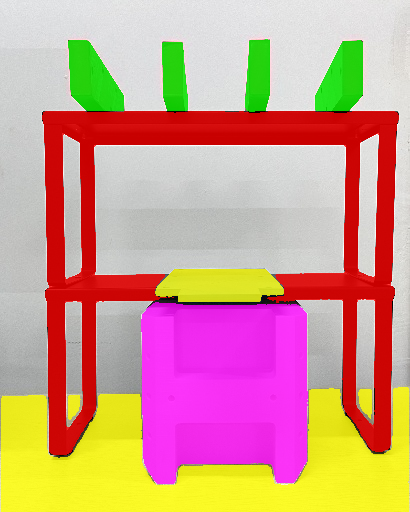

In [29]:
scores = retriev(cropped_boxes, labels)
# print(scores)
indices = get_indices_of_values_above_threshold(scores, 0.2)

# 打开原始图像，绘制overlay
original_image = Image.open(image_path)
overlay_image = Image.new('RGBA', image.size, (0, 0, 0, 0))
overlay_color_map = [
    (255, 0, 0, 200), # 红色
    (0, 255, 0, 200), # 绿色
    (0, 0, 255, 200), # 蓝色
    (255, 255, 0, 200), # 黄色
    (255, 0, 255, 200), # 洋红色
    (0, 255, 255, 200), # 青色
#     (128, 128, 128, 100), # 灰色
#     (255, 165, 0, 100), # 橙色
#     (0, 128, 0, 100), # 深绿色
#     (128, 0, 128, 100), # 紫色
#     (255, 192, 203, 100), # 粉红色
#     (0, 0, 0, 0.5), # 半透明黑色
#     (255, 255, 255, 100), # 半透明白色
#     (100, 200, 50, 100), # 半透明自定义颜色
#     (34, 139, 34, 100), # 森林绿
#     (70, 130, 180, 100), # 天蓝色
#     (255, 218, 185, 100), # 肉色
#     (72, 61, 139, 100), # 暗紫色
#     (255, 20, 147, 100), # 深粉色
#     (70, 130, 180, 100), # 半透明天蓝色
]
draw = ImageDraw.Draw(overlay_image)

for seg_idx, value in enumerate(indices):
    if seg_idx in filter_idxs:
        continue
    if value == -1:
        continue
    segmentation_mask_image = Image.fromarray(masks[seg_idx]["segmentation"].astype('uint8') * 255)
    draw.bitmap((0, 0), segmentation_mask_image, fill=overlay_color_map[value])
    print(seg_idx, value, scores[seg_idx][value])

# for seg_idx, value in enumerate(indices):
#     segmentation_mask_image = Image.fromarray(masks[seg_idx]["segmentation"].astype('uint8') * 255)
#     draw.bitmap((0, 0), segmentation_mask_image, fill=overlay_color_map[seg_idx])
    
result_image = Image.alpha_composite(original_image.convert('RGBA'), overlay_image)
result_image

In [33]:
cropped_boxes[8]

In [31]:
print(cls_list)

['warehouse', 'stringer', 'hand', 'signalinterfaceboard', 'battery', 'framework']
